# **Experiment 2 Data Cleaning**

## Input

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [52]:
cp = pd.read_csv("/content/CarPrice (1).csv") #load csv file

## Data Visualization

In [53]:
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [54]:
cp.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [55]:
cp.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


### Co relation graph with target(Price)

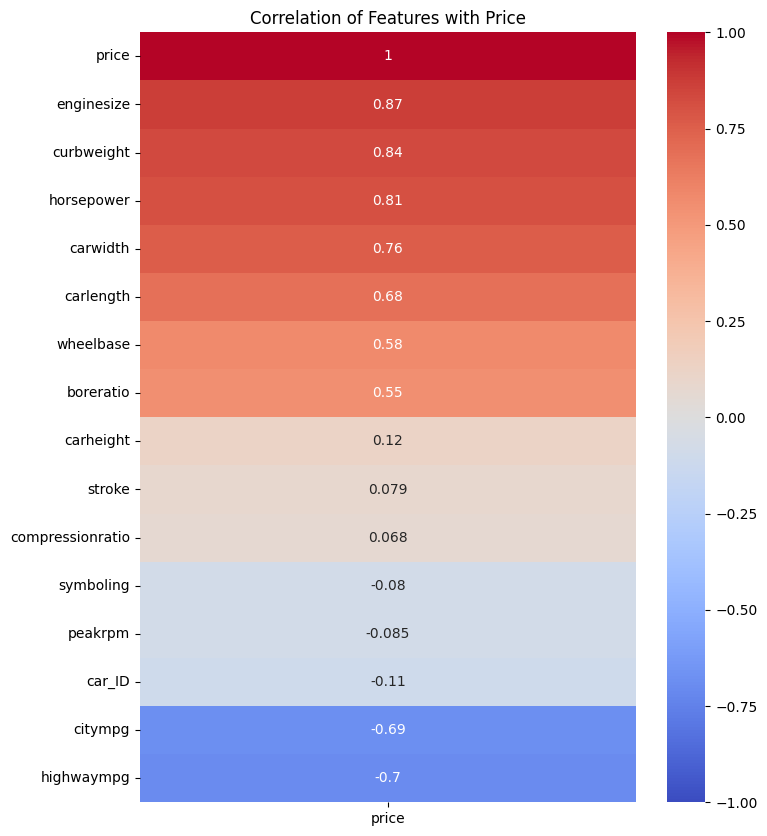

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = cp.corr(numeric_only=True)

# Correlation of all features with price
plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False),
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.title("Correlation of Features with Price")
plt.show()

After studying the correlation graph, I can drop some features that have a weak relationship with the output.

## Data Cleaning

In [57]:
# Drop selected features
cp = cp.drop(columns=[
    'peakrpm',
    'car_ID',
    'symboling',
    'citympg',
    'highwaympg'
])

# Check the remaining columns
print(cp.columns)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'price'],
      dtype='object')


In [58]:
cp.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,13276.710571
std,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,5118.000000
25%,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,10295.000000
75%,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,45400.000000


In [59]:
categorical_cols = cp.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')


In [60]:
X = cp.drop('price', axis=1)
y = cp['price']

In [61]:
print(cp.select_dtypes(include=['object']).columns)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')


In [62]:
X = pd.get_dummies(X, drop_first=True)

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Prediction Accuracy Checking

In [65]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results
print("========== Model Evaluation ==========")
print(f"Training R² Score : {model.score(X_train, y_train):.4f}")
print(f"Testing R² Score  : {r2:.4f}")
print(f"MAE               : {mae:.2f}")
print(f"MSE               : {mse:.2f}")
print(f"RMSE              : {rmse:.2f}")

========== Model Evaluation ==========
Training R² Score : 0.9962
Testing R² Score  : 0.5897
MAE               : 3938.47
MSE               : 32388687.96
RMSE              : 5691.11


If I drop the irrelevant or less-related columns, the accuracy results are:


*   Training R² Score: 0.9962
*   Testing R² Score: 0.5897
*   MAE: 3938.47  
*   MSE: 32388687.96
*   RMSE: 5691.11



However, when I do not drop the less-related features, the results are:



*  Training R² Score: 0.9979
*  Testing R² Score: -1.2391
*  MAE: 7280.67
*  MSE: 176760096.86
*  RMSE: 13295.12



**Conclusion**

**After removing the irrelevant or weakly related features, the model's performance improved significantly on the test data. Although the training R² score decreased slightly (from 0.9979 to 0.9962), the testing R² score improved dramatically from -1.2391 to 0.5897. In addition, the MAE, MSE, and RMSE values decreased substantially, indicating more accurate predictions. This suggests that the removed features were adding noise rather than useful information, causing the model to overfit the training data. Therefore, feature selection improved the model's ability to generalize to unseen data.**


